# Build Coupled Wflow-SFINCS Model

In [1]:
from os.path import join
import os
from pathlib import Path

os.environ.pop("DEBUG", None)

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from hydromt_sfincs import DATADIR, SfincsModel

from design_events.utils import load_runtime
from sfincs_runs.build_base import (
    add_inland_outflow_boundary,
    build_inland_sfincs_domain_set,
    create_native_sfincs_river_handoff_locations,
    plan_inland_sfincs_base,
    plan_inland_sfincs_domain_set,
    plot_sfincs_handoff_basemap,
    sfincs_grid_resolution_matches,
    sfincs_rivers_inflow_geoms,
    set_sfincs_observation_points_from_gages,
    validate_built_sfincs_native_physics,
    write_inland_sfincs_domain_set_manifest,
)
from wflow_runs import (
    build_wflow_data_catalog,
    build_wflow_submodel,
    plot_wflow_basemap,
    plot_wflow_ldd_components,
    wflow_catalog_source_readiness,
    write_wflow_domain_set_manifest,
)
from wflow_runs.notebook import wflow_domain_set_summary, wflow_subbasin_review_table


def configread(path):
    with open(path, encoding="utf-8") as handle:
        return yaml.safe_load(handle)


In [2]:
# Load local packages and this Location Workspace.
notebook_root = Path.cwd().resolve()
location_root = notebook_root.parents[1]
repo_root = location_root.parents[1]
location_name = location_root.name
config, paths = load_runtime(location_root / "config.yaml")
# Wflow domain review policy is workflow policy, not source/model-recipe YAML.
wflow_domain_review_required = False
config["wflow"]["domain_set"]["review_required"] = wflow_domain_review_required


def location_path(value):
    path = Path(value)
    return path if path.is_absolute() else location_root / path

build_wflow = True
build_all_wflow_submodels = True
write_wflow_catalog = True
write_domain_set_manifest = True
run_sfincs_domain_build = True
force_sfincs_domain_build = False
force_wflow_river_build = True
rebuild_wflow_with_boundary_handoffs = True

sfincs_data_catalog = location_root / "data/static/data_catalogue.yaml"
wflow_data_catalog = location_path(config["wflow"]["data_catalog"])
wflow_base_root = location_path(config["wflow"]["base_model_root"])
wflow_network_path = Path(paths["usgs_streamgage_network_geojson"])

data_cols = ["category", "crs", "data_type", "uri"]


## Part 1 — Coupled Domain Plans

Wflow and SFINCS use different geometry meanings: Wflow is hydrologic and can extend upstream; SFINCS is hydraulic coverage around each SMART-DS component.


### Step 1 · Wflow watershed and SFINCS coverage plans

Plan Wflow from the configured hydrologic boundary (`boundary_handoff_watershed`) and plan SFINCS from the selected SMART-DS coverage box. The Wflow boundary-handoff watershed supplies the upstream routing area; the SFINCS domain IDs written here are the hydraulic coupling targets used later by Wflow gauges.


In [3]:
wflow_build_plan, wflow_domain_plan, domain_summary = wflow_domain_set_summary(config, location_root)
sfincs_base_plan = plan_inland_sfincs_base(config, paths)
sfincs_domain_plan = plan_inland_sfincs_domain_set(config, paths)

if sfincs_domain_plan.status == "ready":
    sfincs_domain_manifest = write_inland_sfincs_domain_set_manifest(sfincs_domain_plan, config, paths)
else:
    sfincs_domain_manifest = None

write_domain_set_manifest = wflow_domain_plan.status == "ready"
if write_domain_set_manifest:
    wflow_domain_manifest = write_wflow_domain_set_manifest(wflow_domain_plan, config, paths)
else:
    wflow_domain_manifest = None

domain_set = yaml.safe_load(location_path(config["sfincs_domain_set"]["domain_manifest"]).read_text()) if sfincs_domain_manifest else {"domains": []}
sfincs_domains = list(domain_set["domains"])

display(domain_summary)
display(wflow_subbasin_review_table(wflow_domain_plan))
display(pd.Series({
    "wflow_domain_status": wflow_domain_plan.status,
    "wflow_domain_manifest": str(wflow_domain_manifest.relative_to(repo_root)) if wflow_domain_manifest else "review_required",
    "sfincs_domain_status": sfincs_domain_plan.status,
    "sfincs_domain_manifest": str(sfincs_domain_manifest.relative_to(repo_root)) if sfincs_domain_manifest else "review_required",
    "sfincs_domain_count": sfincs_domain_plan.domain_count,
    "sfincs_handoff_count": sfincs_domain_plan.handoff_count,
}, name="domain_set_plans"))


allow_multiple_submodels                                     True
review_required                                              True
domain_status                    review_required_bbox_placeholder
reviewed_subbasin_plan_status                               ready
hydromt_region_kind                                          bbox
event_catalog_scope                      shared_across_domain_set
configured_submodel_count                                       0
reviewed_submodel_count                                         1
reviewed_handoff_count                                          3
domain_set_manifest                    data/wflow/domain_set.yaml
dtype: object

,wflow_submodel_id,hydromt_region_kind,hydromt_region,handoff_outlet_lon,handoff_outlet_lat,sfincs_domain_ids,sfincs_handoff_ids,gauge_site_nos,frequency_basis
0,greensboro_rural,subbasin,"{'subbasin': [[-79.71772543280319, -79.6476611...","[-79.71772543280319, -79.64766111114379, -79.7...","[36.185092101197306, 36.13997656200044, 36.275...",greensboro_rural,"greensboro_rural_inflow_01, greensboro_rural_i...","02075045, 02075500, 02076000, 02077200, 020773...",greensboro_rural


wflow_domain_status                                                   ready
wflow_domain_manifest       locations/greensboro/data/wflow/domain_set.yaml
sfincs_domain_status                                                  ready
sfincs_domain_manifest    locations/greensboro/data/sfincs/domains/domai...
sfincs_domain_count                                                       1
sfincs_handoff_count                                                      3
Name: domain_set_plans, dtype: object

### Step 2 · Hydrologic boundary and handoff map

Plot the selected Wflow watershed boundary, selected SMART-DS coverage, and planned stream/coverage-box handoff points before any model build. This is the hydrologic handoff check: Wflow owns the upstream watershed, while SFINCS owns only the hydraulic coverage box.


wflow_watershed_features                                   1
wflow_watershed_covers_sfincs_coverage                  True
planned_boundary_handoff_count                             3
max_planned_handoff_distance_from_sfincs_boundary_m    14.84
Name: domain_plan_hydrologic_boundary_check, dtype: object

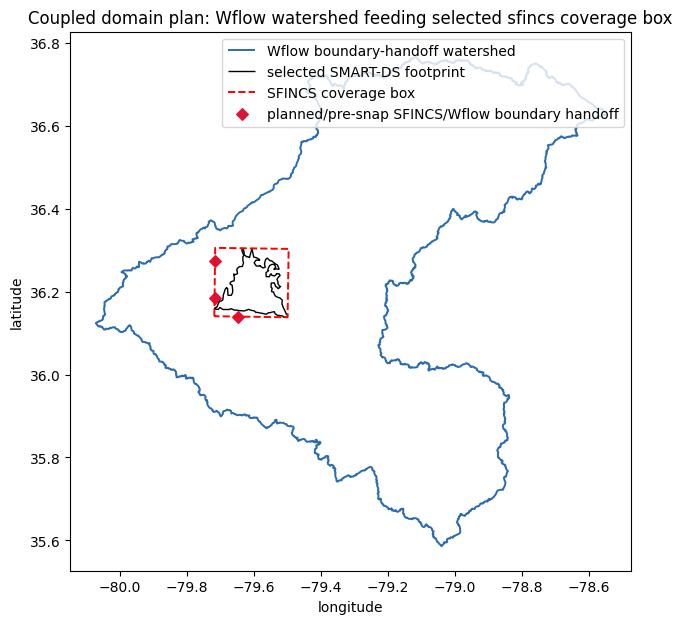

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))

sfincs_domain_layers = [gpd.read_file(location_path(domain["region"])) for domain in sfincs_domains]
sfincs_domain_gdf = pd.concat(sfincs_domain_layers, ignore_index=True)
sfincs_domain_gdf = gpd.GeoDataFrame(sfincs_domain_gdf, geometry="geometry", crs=sfincs_domain_layers[0].crs).to_crs(4326)
sfincs_label = "SFINCS coverage box" if len(sfincs_domain_gdf) == 1 else "SFINCS coverage boxes"
sfincs_coverage_geom = sfincs_domain_gdf.geometry.union_all()

# Wflow build geometry is the HUC/HUC-union watershed selected in 01_region_setup,
# not the older NHDPlus review fabric that only documents candidate catchments.
wflow_watershed_layers = []
for submodel in wflow_domain_plan.submodels:
    watershed_path = submodel.get("subbasin_geometry")
    if watershed_path:
        watershed = gpd.read_file(location_path(watershed_path)).to_crs(4326)
        watershed["wflow_submodel_id"] = submodel["wflow_submodel_id"]
        wflow_watershed_layers.append(watershed)

if not wflow_watershed_layers:
    watershed_path = config["static_sources"]["wflow_collection_extent"]["watersheds"]
    wflow_watershed_layers.append(gpd.read_file(location_path(watershed_path)).to_crs(4326))

wflow_watershed_gdf = gpd.GeoDataFrame(
    pd.concat(wflow_watershed_layers, ignore_index=True),
    geometry="geometry",
    crs=wflow_watershed_layers[0].crs,
).to_crs(4326)
wflow_watershed_gdf.boundary.plot(ax=ax, color="#2b6cb0", linewidth=1.4, label="Wflow boundary-handoff watershed")

study = gpd.read_file(location_root / "data/static/aoi/evaluation_footprint.geojson").to_crs(4326)
study_components = study.explode(index_parts=False).reset_index(drop=True)
selected_study = study_components[study_components.intersects(sfincs_coverage_geom)].copy()
if not selected_study.empty:
    selected_study.boundary.plot(ax=ax, color="black", linewidth=1.0, label="selected SMART-DS footprint")

sfincs_domain_gdf.boundary.plot(ax=ax, color="red", linewidth=1.4, linestyle="--", label=sfincs_label)

handoff_records = []
for submodel in wflow_domain_plan.submodels:
    for point in submodel.get("handoff_points", []):
        handoff_records.append({
            "sfincs_handoff_id": point["sfincs_handoff_id"],
            "wflow_submodel_id": submodel["wflow_submodel_id"],
            "sfincs_domain_id": point.get("sfincs_domain_id"),
            "uparea_km2": point.get("uparea_km2"),
            "geometry": gpd.points_from_xy([point["lon"]], [point["lat"]])[0],
        })

handoff_plan_gdf = gpd.GeoDataFrame(handoff_records, geometry="geometry", crs="EPSG:4326")
if not handoff_plan_gdf.empty:
    handoff_plan_gdf.plot(
        ax=ax,
        marker="D",
        color="crimson",
        markersize=35,
        label="planned/pre-snap SFINCS/Wflow boundary handoff",
    )

wflow_watershed_geom = wflow_watershed_gdf.geometry.union_all()
planned_handoff_boundary_distance_m = None
if not handoff_plan_gdf.empty:
    model_crs = config["sfincs"].get("model_crs", "EPSG:32617")
    boundary = sfincs_domain_gdf.to_crs(model_crs).geometry.union_all().boundary
    distances = handoff_plan_gdf.to_crs(model_crs).geometry.distance(boundary)
    planned_handoff_boundary_distance_m = float(distances.max())

display(pd.Series({
    "wflow_watershed_features": int(len(wflow_watershed_gdf)),
    "wflow_watershed_covers_sfincs_coverage": bool(wflow_watershed_geom.covers(sfincs_coverage_geom)),
    "planned_boundary_handoff_count": int(len(handoff_plan_gdf)),
    "max_planned_handoff_distance_from_sfincs_boundary_m": round(planned_handoff_boundary_distance_m, 3) if planned_handoff_boundary_distance_m is not None else "no planned handoffs",
}, name="domain_plan_hydrologic_boundary_check"))

ax.set_title(f"Coupled domain plan: Wflow watershed feeding selected {sfincs_label.lower()}")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.legend(loc="best")


## Part 2 — HydroMT-Wflow Native Build

Wflow is built first because its DEM/LDD-derived `staticgeoms/rivers.geojson` is the authoritative stream linework for SFINCS source placement.


### Step 3 · HydroMT-Wflow data catalog readiness

HydroMT-Wflow needs the local DEM-derived hydrography basemap, landcover, soil parameter maps, and event forcing sources before the submodels can be built.


In [5]:
wflow_catalog_path = build_wflow_data_catalog(config, paths) if write_wflow_catalog else wflow_data_catalog
wflow_source_readiness = pd.DataFrame(wflow_catalog_source_readiness(wflow_catalog_path))
missing_required_wflow_source = (
    wflow_source_readiness["required_for_build"].fillna(False).astype(bool)
    & wflow_source_readiness["local_file"].fillna(False).astype(bool)
    & ~wflow_source_readiness["exists"].fillna(False).astype(bool)
)
required_wflow_sources_missing = wflow_source_readiness[missing_required_wflow_source]

if not required_wflow_sources_missing.empty:
    display(wflow_source_readiness)
    raise FileNotFoundError("Missing required HydroMT-Wflow source files before build")

wflow_source_readiness


,source,data_type,uri,local_file,exists,required_for_build,status,category
0,us_hydrography_basemap,RasterDataset,/home/grahamhults/projects/Flood-RM/locations/...,True,True,True,review_required,hydrography
1,greensboro_streamgage_network,GeoDataFrame,/home/grahamhults/projects/Flood-RM/locations/...,True,True,False,NaN,hydrography
2,nhdplus_hr_river_geometry,GeoDataFrame,/home/grahamhults/projects/Flood-RM/locations/...,True,True,True,NaN,hydrography
3,esa_worldcover,RasterDataset,/home/grahamhults/projects/Flood-RM/locations/...,True,True,True,NaN,landuse
4,ssurgo_hydrologic_soil_group,RasterDataset,/home/grahamhults/projects/Flood-RM/locations/...,True,True,False,NaN,soils
5,ssurgo_saturated_conductivity,RasterDataset,/home/grahamhults/projects/Flood-RM/locations/...,True,True,False,NaN,soils
6,ssurgo_wflow_soil_parameters,RasterDataset,/home/grahamhults/projects/Flood-RM/locations/...,True,True,True,review_required,soils
7,event_precip,RasterDataset,/home/grahamhults/projects/Flood-RM/locations/...,False,None,False,NaN,event_forcing
8,event_temp_pet,RasterDataset,/home/grahamhults/projects/Flood-RM/locations/...,False,None,False,NaN,event_forcing


### Step 4 · Wflow build steps

Inspect the HydroMT-Wflow workflow. `build_wflow_submodel` keeps this syntax but replaces the template region with each reviewed `subbasin + uparea` outlet region.


In [6]:
wf_config = configread(str(location_path(config["wflow"]["build_config"])))
print(wf_config.keys())
pd.DataFrame({"step": [next(iter(step)) for step in wf_config.get("steps", [])]})


dict_keys(['steps'])


,step
0,setup_config
1,setup_basemaps
2,setup_rivers
3,setup_lulcmaps
4,setup_soilmaps
5,setup_constant_pars
6,setup_gauges


### Step 5 · Build or reuse Wflow submodels

Each Wflow submodel is the configured hydrologic domain from `wflow.domain_set` (for `boundary_handoff_watershed`, one upstream handoff watershed per SFINCS coverage box). This first pass guarantees that HydroMT-Wflow-native rivers, basins, gauges, and static maps are available before SFINCS source placement.


In [7]:
if wflow_domain_plan.status != "ready":
    raise RuntimeError(f"Wflow Domain Set requires review before build: {wflow_domain_plan.status}: {wflow_domain_plan.issues}")
if sfincs_domain_plan.status != "ready":
    raise RuntimeError(f"SFINCS coverage domains require review before build: {sfincs_domain_plan.status}: {sfincs_domain_plan.issues}")

selected_submodels = wflow_domain_plan.submodels if build_all_wflow_submodels else wflow_domain_plan.submodels[:1]
wflow_native_build_summary = []
if build_wflow:
    for submodel in selected_submodels:
        submodel_id = submodel["wflow_submodel_id"]
        river_fn = wflow_base_root / submodel_id / "staticgeoms/rivers.geojson"
        wflow_native_build_summary.append(
            build_wflow_submodel(
                config,
                paths,
                submodel_id=submodel_id,
                force=force_wflow_river_build or not river_fn.exists(),
                write_catalog=False,
            )
        )

wflow_models = {summary["wflow_submodel_id"]: summary["model"] for summary in wflow_native_build_summary}
pd.DataFrame([{k: v for k, v in summary.items() if k != "model"} for summary in wflow_native_build_summary])


2026-06-20 15:16:37,380 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/data_catalog.yml
2026-06-20 15:16:37,425 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.2).
2026-06-20 15:16:37,426 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/hydromt_wflow/data/parameters_data.yml
2026-06-20 15:16:37,442 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-06-20 15:16:37,443 - hydromt.hydromt_wflow.components.config - config - INFO - Reading default config file from /home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/hydromt_wflow/data/wflow_sbm/wflow_sbm.toml.
2026-06-20 15:16:37,446 - hydromt - log - INFO - HydroMT version: 1.3.1
2026-06-20 15:16:37,447 - hydromt.model.model -

,status,wflow_submodel_id,base_model_root,data_catalog,gauges_fn,gauge_count,observation_gauges_fn,observation_gauge_count,built,staticmap_qa_status
0,built,greensboro_rural,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,3,/home/grahamhults/projects/Flood-RM/locations/...,33,True,failed


### Step 6 · Wflow static map inventory

List the HydroMT-Wflow static maps and static geometries produced by `setup_basemaps`, `setup_rivers`, and `setup_gauges` before trusting any handoff point.


In [8]:
wflow_inventory_rows = []
wflow_native_handoff_rows = []

for submodel in selected_submodels:
    submodel_id = submodel["wflow_submodel_id"]
    wf = wflow_models[submodel_id]
    staticmaps_path = wflow_base_root / submodel_id / "staticmaps.nc"

    for name, data_array in wf.staticmaps.data.data_vars.items():
        values = data_array.values
        wflow_inventory_rows.append({
            "wflow_submodel_id": submodel_id,
            "artifact": "staticmaps",
            "name": name,
            "item_kind": "cells",
            "item_count": int(data_array.size),
            "finite_cells": int(pd.notna(values).sum()),
            "missing_cells": int(pd.isna(values).sum()),
            "dimensions": " x ".join(f"{dim}={size}" for dim, size in data_array.sizes.items()),
            "artifact_path": str(staticmaps_path.relative_to(repo_root)),
            "exists_on_disk": staticmaps_path.exists(),
        })
    for name, geom in wf.geoms.data.items():
        geom_path = wflow_base_root / submodel_id / "staticgeoms" / f"{name}.geojson"
        wflow_inventory_rows.append({
            "wflow_submodel_id": submodel_id,
            "artifact": "staticgeoms",
            "name": name,
            "item_kind": "features",
            "item_count": int(len(geom)),
            "artifact_path": str(geom_path.relative_to(repo_root)),
            "exists_on_disk": geom_path.exists(),
        })

    planned_handoffs = submodel.get("sfincs_handoff_ids", [])
    native_handoffs = wf.geoms.data.get("gauges_sfincs")
    native_handoff_ids = [] if native_handoffs is None else sorted(native_handoffs["name"].astype(str).tolist())
    wflow_native_handoff_rows.append({
        "wflow_submodel_id": submodel_id,
        "planned_boundary_crossings": len(planned_handoffs),
        "native_snapped_wflow_gauges": len(native_handoff_ids),
        "native_gauge_ids": ", ".join(native_handoff_ids),
    })

# Planned crossings mark every SFINCS boundary/river intersection; HydroMT snaps only those represented on routed Wflow cells.
missing_disk_artifacts = sorted({row["artifact_path"] for row in wflow_inventory_rows if not row["exists_on_disk"]})
if missing_disk_artifacts:
    raise FileNotFoundError(
        "Wflow build did not write required artifacts; rerun Step 5 to completion before continuing: "
        + ", ".join(missing_disk_artifacts)
    )

display(pd.DataFrame(wflow_native_handoff_rows))
pd.DataFrame(wflow_inventory_rows)


,wflow_submodel_id,planned_boundary_crossings,native_snapped_wflow_gauges,native_gauge_ids
0,greensboro_rural,3,3,"greensboro_rural_inflow_01, greensboro_rural_i..."


,wflow_submodel_id,artifact,name,item_kind,item_count,finite_cells,missing_cells,dimensions,artifact_path,exists_on_disk
0,greensboro_rural,staticmaps,local_drain_direction,cells,175441,175441.0,0.0,y=353 x x=497,locations/greensboro/data/wflow/base/greensbor...,True
1,greensboro_rural,staticmaps,subcatchment,cells,175441,175441.0,0.0,y=353 x x=497,locations/greensboro/data/wflow/base/greensbor...,True
2,greensboro_rural,staticmaps,meta_upstream_area,cells,175441,83881.0,91560.0,y=353 x x=497,locations/greensboro/data/wflow/base/greensbor...,True
3,greensboro_rural,staticmaps,meta_streamorder,cells,175441,83881.0,91560.0,y=353 x x=497,locations/greensboro/data/wflow/base/greensbor...,True
4,greensboro_rural,staticmaps,meta_subgrid_area,cells,175441,175441.0,0.0,y=353 x x=497,locations/greensboro/data/wflow/base/greensbor...,True
5,greensboro_rural,staticmaps,land_elevation,cells,175441,175441.0,0.0,y=353 x x=497,locations/greensboro/data/wflow/base/greensbor...,True
6,greensboro_rural,staticmaps,land_slope,cells,175441,175441.0,0.0,y=353 x x=497,locations/greensboro/data/wflow/base/greensbor...,True
7,greensboro_rural,staticmaps,river_mask,cells,175441,175441.0,0.0,y=353 x x=497,locations/greensboro/data/wflow/base/greensbor...,True
8,greensboro_rural,staticmaps,river_length,cells,175441,175441.0,0.0,y=353 x x=497,locations/greensboro/data/wflow/base/greensbor...,True
9,greensboro_rural,staticmaps,river_slope,cells,175441,175441.0,0.0,y=353 x x=497,locations/greensboro/data/wflow/base/greensbor...,True


### Step 7 · Wflow native basemap plots

Plot elevation, adaptive HydroMT-Wflow river vectors, basins, gauges, and SFINCS coverage boxes using the built Wflow model objects and their native `staticmaps` / `geoms` artifacts. Lower-order vector streams are only added where they intersect SFINCS domains so handoff crossings remain visible without plotting raster river cells.


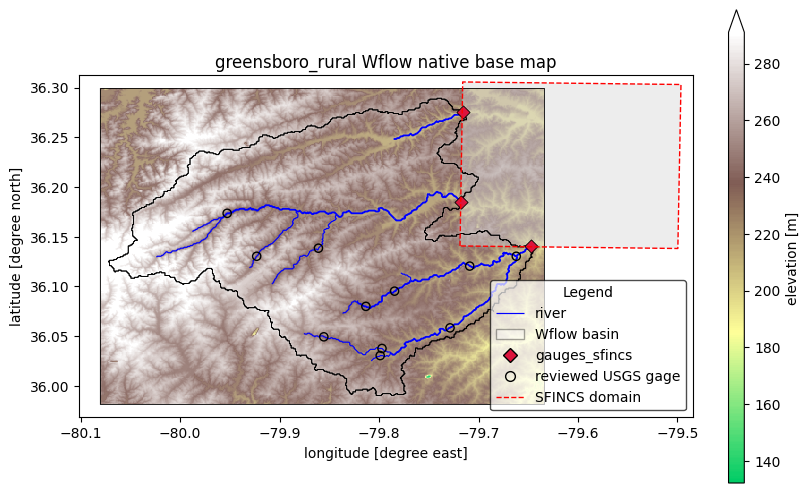

In [9]:
for submodel_id, wf in wflow_models.items():
    observation_gages_path = wflow_base_root.parent / "domain_set_gauges" / f"{submodel_id}_observation_gauges.geojson"
    observation_gages = gpd.read_file(observation_gages_path) if observation_gages_path.exists() else None
    fig, ax = plot_wflow_basemap(wf, gages=observation_gages, sfincs_domains=sfincs_domain_gdf, figsize=(8, 6), title=f"{submodel_id} Wflow native base map")
    fig.savefig(wflow_base_root / submodel_id / "wflow_native_basemap.png", dpi=450, bbox_inches="tight")


### Step 8 · Wflow LDD component plots

Inspect the flow-aware layers that control handoff placement: elevation, upstream area, stream order, and local drain direction.


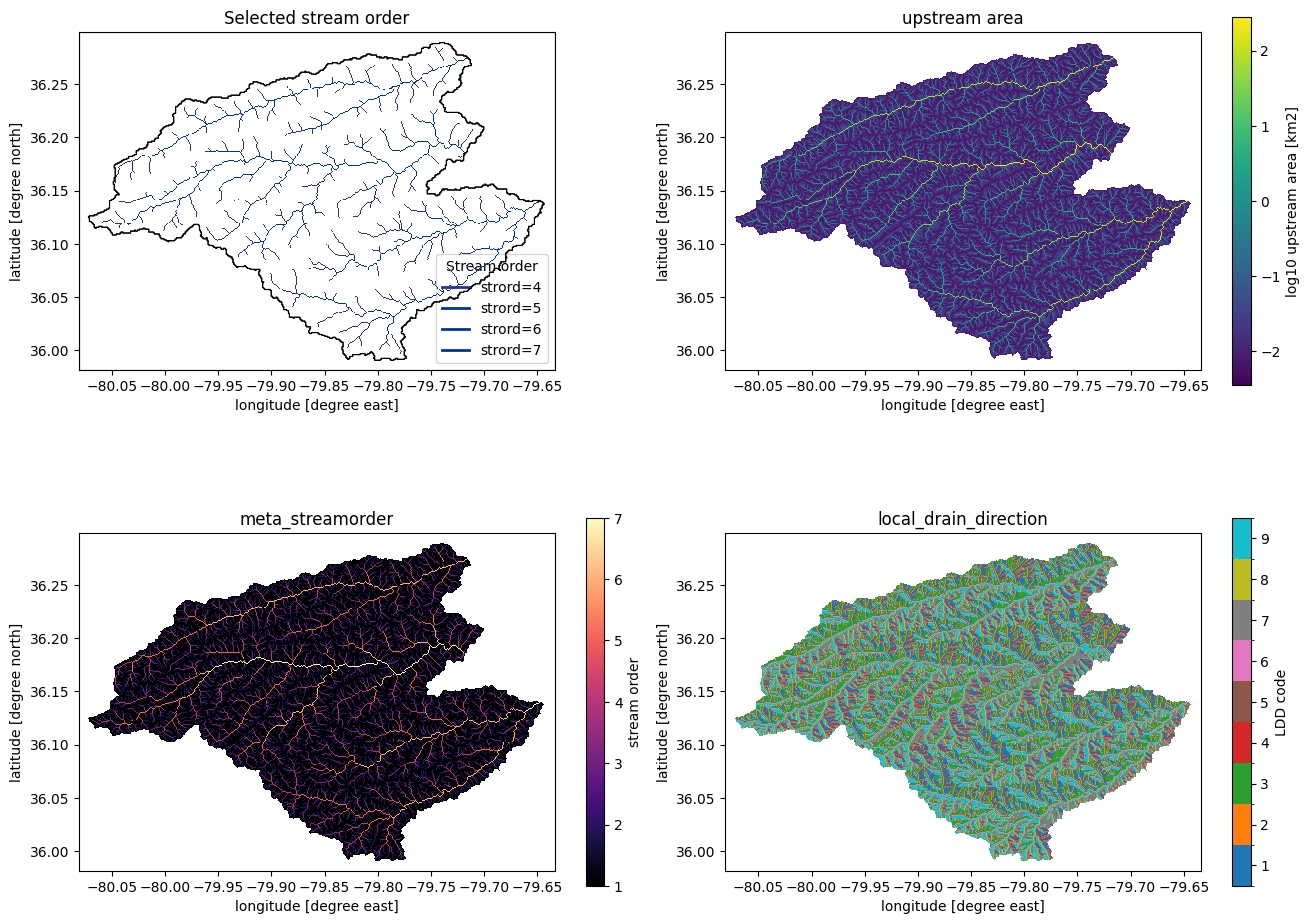

In [10]:
for submodel_id, wf in wflow_models.items():
    fig, _ = plot_wflow_ldd_components(wf)
    fig.savefig(wflow_base_root / submodel_id / "wflow_ldd_components_native.png", dpi=300, bbox_inches="tight")


## Part 3 — HydroMT-SFINCS Coverage Build

SFINCS domains are hydraulic coverage boxes around SMART-DS components. They are not assumed to be full watersheds.


### Step 9 · Initialize SFINCS coverage models

Each SMART-DS coverage box gets its own `SfincsModel` root. The discharge sources are added after Wflow-native rivers are available.


In [11]:
sfincs_models = {}
sfincs_model_rows = []

for domain in sfincs_domains:
    sfincs_domain_id = domain["sfincs_domain_id"]
    root = location_path(domain["base_model_root"])
    expected_sfincs_res_m = float(config["sfincs"]["grid_resolution_m"])
    sfincs_model_resolution_ready = sfincs_grid_resolution_matches(root, expected_sfincs_res_m)
    sfincs_model_ready = (root / "sfincs.inp").exists() and sfincs_model_resolution_ready
    sfincs_model_mode = "w+" if force_sfincs_domain_build or not sfincs_model_ready else "r+"
    sf = SfincsModel(
        root=str(root),
        mode=sfincs_model_mode,
        data_libs=[str(sfincs_data_catalog), str(wflow_data_catalog)],
    )
    sfincs_models[sfincs_domain_id] = sf
    sfincs_model_rows.append({
        "sfincs_domain_id": sfincs_domain_id,
        "region": str(location_path(domain["region"]).relative_to(repo_root)),
        "base_model_root": str(root.relative_to(repo_root)),
        "handoff_source_count": len(domain["handoff_source_ids"]),
        "grid_resolution_m": expected_sfincs_res_m,
        "existing_grid_matches_resolution": sfincs_model_resolution_ready,
    })

sf_data = ["dem_region", "landcover_region", "hydrologic_soil_group", "saturated_conductivity"]
display(next(iter(sfincs_models.values())).data_catalog._to_dataframe().loc[sf_data, data_cols])
pd.DataFrame(sfincs_model_rows)


2026-06-20 15:18:38,425 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/locations/greensboro/data/static/data_catalogue.yaml
2026-06-20 15:18:38,436 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/data_catalog.yml
2026-06-20 15:18:38,443 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-06-20 15:18:38,444 - hydromt.model.model - model - WARNING - No region component found in components.


,category,crs,data_type,uri
name,,,,
dem_region,topography,4269.0,RasterDataset,processed/dem_region_setup.tif
landcover_region,landuse,4269.0,RasterDataset,processed/landcover_region_setup.tif
hydrologic_soil_group,soils,4269.0,RasterDataset,soils/hsg_greensboro.tif
saturated_conductivity,soils,4269.0,RasterDataset,soils/ksat_mmhr_greensboro.tif


,sfincs_domain_id,region,base_model_root,handoff_source_count,grid_resolution_m,existing_grid_matches_resolution
0,greensboro_rural,locations/greensboro/data/sfincs/domains/green...,locations/greensboro/data/sfincs/domains/green...,3,60.0,True


### Step 10 · SFINCS build configuration

Use the standard HydroMT-SFINCS build recipe for the grid, elevation, masks, and subgrid. The Wflow coupling sources are then created with HydroMT-SFINCS native river inflow tooling from the Wflow hydrography catalog.


In [12]:
sf_config = configread(str(location_root / config["includes"]["sfincs_build"]))
sf_config["setup_grid_from_region"]["res"] = config["sfincs"]["grid_resolution_m"]
sf_config["setup_grid_from_region"]["crs"] = config["sfincs"].get("model_crs", config["project"]["model_crs"])
sf_config["setup_dep"]["datasets_dep"] = [{"elevtn": "dem_region"}]
sf_config["setup_subgrid"]["datasets_dep"] = [{"elevtn": "dem_region"}]
sf_config["setup_subgrid"]["datasets_rgh"] = [{"lulc": "landcover_region"}]
sf_config.pop("setup_river_outflow", None)
print(sf_config.keys())


dict_keys(['setup_grid_from_region', 'setup_dep', 'setup_mask_active', 'setup_mask_bounds', 'setup_subgrid'])


### Step 11 · Build or reuse SFINCS grids, masks, subgrid, and Wflow source points

The source GeoJSON is written after the SFINCS grid exists so HydroMT-SFINCS can place discharge points where river centerlines enter the hydraulic domain. Wflow then uses those SFINCS `src` points as its handoff gauges.


In [13]:
sfincs_build_report = pd.DataFrame()
if run_sfincs_domain_build:
    sfincs_build_report = build_inland_sfincs_domain_set(
        config,
        paths,
        force=force_sfincs_domain_build,
    )

sfincs_models = {}
sfincs_build_rows = []
handoff_layers = []

for domain in sfincs_domains:
    domain_id = domain["sfincs_domain_id"]
    root = location_path(domain["base_model_root"])
    validate_built_sfincs_native_physics(root, config)

    sf = SfincsModel(
        root=str(root),
        mode="r+",
        data_libs=[str(sfincs_data_catalog), str(wflow_data_catalog)],
    )
    sf.read()
    sfincs_models[domain_id] = sf

    handoff_locations = root / "gis/wflow_handoff_sources.geojson"
    create_native_sfincs_river_handoff_locations(
        sf,
        config,
        paths,
        output=handoff_locations,
        sfincs_domain_id=domain_id,
        wflow_submodel_id=next(iter(domain.get("wflow_submodel_ids", [])), None),
        handoff_source_ids=domain.get("handoff_source_ids", ()),
    )
    sf.write()
    src = gpd.read_file(handoff_locations)
    rivers = sfincs_rivers_inflow_geoms(sf)
    handoff_layers.append(src)
    sfincs_build_rows.append({
        "sfincs_domain_id": domain_id,
        "built": domain_id in set(sfincs_build_report.get("sfincs_domain_id", [])),
        "grid_resolution_m": float(config["sfincs"]["grid_resolution_m"]),
        "rivers_inflow_features": int(len(rivers)),
        "root": str(root.relative_to(repo_root)),
    })

pd.DataFrame(sfincs_build_rows)


2026-06-20 15:18:38,550 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-06-20 15:18:38,551 - hydromt.model.model - model - WARNING - No region component found in components.
2026-06-20 15:18:38,650 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask
2026-06-20 15:18:38,652 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: dep
2026-06-20 15:18:38,653 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: manning
2026-06-20 15:18:38,655 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: smax
2026-06-20 15:18:38,656 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: seff
2026-06-20 15:18:38,658 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: ks
2026-06-20 15:18:39,906 - hydromt.hydromt_sfincs.components.output - output - WARNING - File /home/grahamhults/projects/Flood-RM/locations/greensboro/data/sfincs/domains/g

,sfincs_domain_id,built,grid_resolution_m,rivers_inflow_features,root
0,greensboro_rural,True,60.0,22,locations/greensboro/data/sfincs/domains/green...


### Step 12 · SFINCS coverage QA plots

Plot each SFINCS coverage grid with reviewed gages, HydroMT-SFINCS native `rivers_inflow` linework, and Wflow->SFINCS source points.


,sfincs_domain_id,discharge_sources_src,unique_discharge_source_locations,visible_wflow_native_river_features,reviewed_usgs_gages_visible,outflow_boundary_cells_mask3,min_src_to_outflow_distance_m
0,greensboro_rural,3,3,22,1,64,10296.4


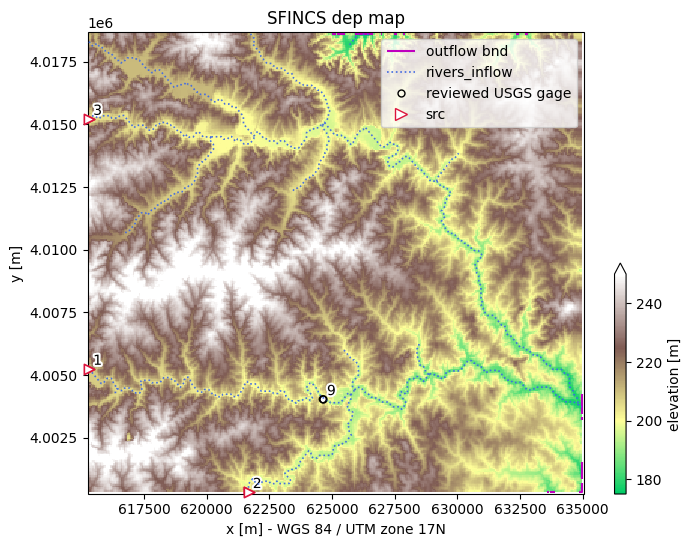

In [14]:
handoff_gdf = pd.concat(handoff_layers, ignore_index=True)
handoff_gdf = gpd.GeoDataFrame(handoff_gdf, geometry="geometry", crs=handoff_layers[0].crs)

from hydromt_sfincs.utils import get_bounds_vector

sfincs_coupling_qa = []
for domain in sfincs_domains:
    sfincs_domain_id = domain["sfincs_domain_id"]
    sf = sfincs_models[sfincs_domain_id]
    sf.elevation.data["dep"].attrs.update(long_name="elevation", units="m")
    handoff_locations = location_path(domain["base_model_root"]) / "gis/wflow_handoff_sources.geojson"
    rivers = sfincs_rivers_inflow_geoms(sf)
    observations = gpd.GeoDataFrame(columns=["geometry"], geometry="geometry", crs=sf.crs)
    if wflow_network_path.exists():
        observations = set_sfincs_observation_points_from_gages(sf, wflow_network_path)

    # plot_bounds draws the mask=3 outflow boundary. In the coupled Wflow->SFINCS
    # model these are distinct from src points, which are Wflow inflows at stream
    # and coverage-box crossings.
    fig, ax, plot_qa = plot_sfincs_handoff_basemap(
        sf,
        handoff_sources=handoff_locations,
        rivers=rivers,
        observations=observations,
        config=config,
        paths=paths,
        domain_region=domain["region"],
        figsize=(8, 6),
    )
    fig.savefig(join(sf.root.path, "sfincs_basemap.png"), dpi=450, bbox_inches="tight")

    # Coupling QA: confirm both boundary types exist and the inflow sources are not sitting
    # on the outflow boundary (a ~0 m distance would mean conflicting boundary conditions).
    src_pts = sf.discharge_points.gdf
    mask = sf.grid.data["mask"]
    outflow_bnd = get_bounds_vector(mask)
    outflow_bnd = outflow_bnd[outflow_bnd["value"] == 3]
    if not outflow_bnd.empty and not src_pts.empty:
        outflow_line = outflow_bnd.to_crs(src_pts.crs).geometry.union_all()
        min_src_to_outflow_m = round(float(src_pts.geometry.distance(outflow_line).min()), 1)
    else:
        min_src_to_outflow_m = "no outflow bnd / no src"
    sfincs_coupling_qa.append({
        "sfincs_domain_id": sfincs_domain_id,
        **plot_qa,
        "outflow_boundary_cells_mask3": int((mask == 3).sum()),
        "min_src_to_outflow_distance_m": min_src_to_outflow_m,
    })

pd.DataFrame(sfincs_coupling_qa)


### Step 13 · SFINCS handoff source table

Review the source coordinates and their river-intersection provenance before rebuilding Wflow gauges.


In [15]:
handoff_columns = [
    "sfincs_domain_id",
    "sfincs_handoff_id",
    "wflow_submodel_id",
    "site_no",
    "handoff_placement",
    "handoff_location_review_status",
    "stream_boundary_river_source",
    "stream_boundary_candidate_count",
]
handoff_columns = [column for column in handoff_columns if column in handoff_gdf.columns]
handoff_gdf[handoff_columns]


,sfincs_domain_id,sfincs_handoff_id,wflow_submodel_id,site_no,handoff_placement,handoff_location_review_status,stream_boundary_river_source
0,greensboro_rural,greensboro_rural_inflow_01,greensboro_rural,greensboro_rural_inflow_01,sfincs_native_river_inflow,hydromt_sfincs_native_river_inflow,us_hydrography_basemap
1,greensboro_rural,greensboro_rural_inflow_02,greensboro_rural,greensboro_rural_inflow_02,sfincs_native_river_inflow,hydromt_sfincs_native_river_inflow,us_hydrography_basemap
2,greensboro_rural,greensboro_rural_inflow_03,greensboro_rural,greensboro_rural_inflow_03,sfincs_native_river_inflow,hydromt_sfincs_native_river_inflow,us_hydrography_basemap


## Part 4 — Coupling Back Into Wflow

After SFINCS writes boundary source points, Wflow is rebuilt with gauge outputs at exactly those source points. Each Wflow hydrologic domain may be much larger than its SFINCS coverage box.


### Step 14 · Rebuild Wflow gauges at SFINCS boundary sources

This second Wflow pass keeps the same HydroMT-Wflow hydrologic domains and static maps, but the `setup_gauges` SFINCS layer now reads the SFINCS boundary-source GeoJSONs.


In [16]:
wflow_build_summary = []
if build_wflow:
    for submodel in selected_submodels:
        wflow_build_summary.append(
            build_wflow_submodel(
                config,
                paths,
                submodel_id=submodel["wflow_submodel_id"],
                force=rebuild_wflow_with_boundary_handoffs,
                write_catalog=False,
            )
        )

wflow_models = {summary["wflow_submodel_id"]: summary["model"] for summary in wflow_build_summary}
pd.DataFrame([{k: v for k, v in summary.items() if k != "model"} for summary in wflow_build_summary])


2026-06-20 15:18:47,484 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/data_catalog.yml
2026-06-20 15:18:47,492 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.2).
2026-06-20 15:18:47,493 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/hydromt_wflow/data/parameters_data.yml
2026-06-20 15:18:47,510 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-06-20 15:18:47,511 - hydromt.hydromt_wflow.components.config - config - INFO - Reading default config file from /home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/hydromt_wflow/data/wflow_sbm/wflow_sbm.toml.
2026-06-20 15:18:47,512 - hydromt - log - INFO - HydroMT version: 1.3.1
2026-06-20 15:18:47,514 - hydromt.model.model -

,status,wflow_submodel_id,base_model_root,data_catalog,gauges_fn,gauge_count,observation_gauges_fn,observation_gauge_count,built,staticmap_qa_status
0,built,greensboro_rural,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,3,/home/grahamhults/projects/Flood-RM/locations/...,33,True,failed


### Step 15 · Final coupled Wflow basemaps

Plot the native Wflow model with filled Wflow basin and SFINCS coverage areas, Wflow-native river vectors, and the model's `gauges_sfincs` layer. This is the main check that the upstream Wflow model feeds the right hydraulic coverage box boundaries.


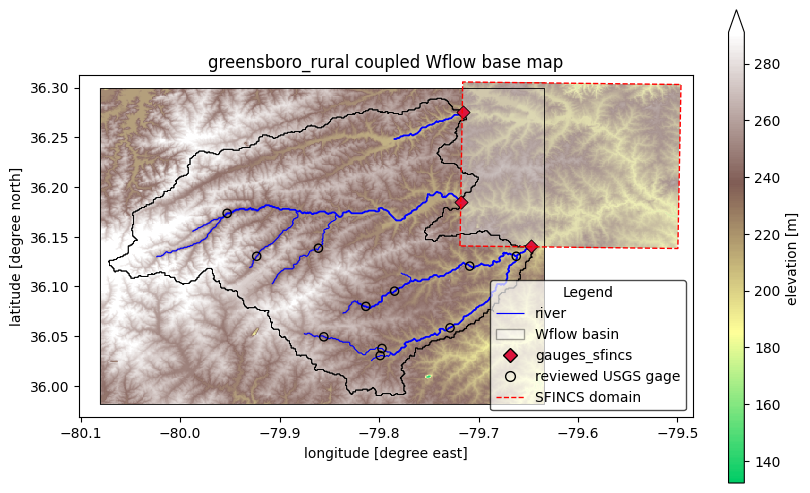

In [17]:
sfincs_background_elevation = [sf.elevation.data["dep"] for sf in sfincs_models.values()]
for submodel_id, wf in wflow_models.items():
    observation_gages_path = wflow_base_root.parent / "domain_set_gauges" / f"{submodel_id}_observation_gauges.geojson"
    observation_gages = gpd.read_file(observation_gages_path) if observation_gages_path.exists() else None
    fig, ax = plot_wflow_basemap(
        wf,
        gages=observation_gages,
        sfincs_domains=sfincs_domain_gdf,
        background_elevation=sfincs_background_elevation,
        figsize=(8, 6),
        title=f"{submodel_id} coupled Wflow base map",
    )
    fig.savefig(wflow_base_root / submodel_id / "wflow_basemap.png", dpi=450, bbox_inches="tight")


### Step 16 · Final Wflow gauge QA

List the Wflow gauge layers that will produce discharge for SFINCS and verify each SFINCS source maps to one nearby Wflow gauge. The LDD/staticmaps are not replotted here because gauge insertion does not change them.


In [18]:
gauge_rows = []
handoff_contract_rows = []
model_crs = config["sfincs"].get("model_crs", config["project"].get("model_crs", "EPSG:32617"))
max_allowed_handoff_snap_m = float(config["sfincs"].get("grid_resolution_m", 100))

for submodel_id, wf in wflow_models.items():
    for name, geom in wf.geoms.data.items():
        if name.startswith("gauges") or name.startswith("subcatchment"):
            gauge_rows.append({"wflow_submodel_id": submodel_id, "geometry_layer": name, "feature_count": len(geom)})

    sfincs_gauges = wf.geoms.data.get("gauges_sfincs")
    if sfincs_gauges is None or sfincs_gauges.empty:
        raise ValueError(f"{submodel_id} has no gauges_sfincs layer for SFINCS discharge handoff.")

    sources = handoff_gdf[handoff_gdf["wflow_submodel_id"].astype(str).eq(str(submodel_id))].to_crs(model_crs)
    if sources.empty:
        raise ValueError(f"{submodel_id} has no SFINCS handoff sources to couple back to Wflow.")

    gauges = sfincs_gauges.to_crs(model_crs).copy()
    source_ids = set(sources["sfincs_handoff_id"].astype(str))
    gauge_ids = set(gauges["sfincs_handoff_id"].astype(str)) if "sfincs_handoff_id" in gauges else set(gauges["name"].astype(str))
    missing_in_wflow = sorted(source_ids - gauge_ids)
    stale_in_wflow = sorted(gauge_ids - source_ids)
    if missing_in_wflow or stale_in_wflow:
        raise RuntimeError(
            f"{submodel_id} gauges_sfincs is stale relative to current SFINCS handoff sources. "
            f"Missing in Wflow: {missing_in_wflow or 'none'}; stale in Wflow: {stale_in_wflow or 'none'}. "
            "Rerun Step 14 with rebuild_wflow_with_boundary_handoffs=True, then rerun Steps 15-16."
        )
    for _, source in sources.iterrows():
        gauge_id = str(source["sfincs_handoff_id"])
        matched_gauges = gauges[gauges["sfincs_handoff_id"].astype(str).eq(gauge_id)] if "sfincs_handoff_id" in gauges else gauges[gauges["name"].astype(str).eq(gauge_id)]
        distances = matched_gauges.geometry.distance(source.geometry)
        nearest_index = distances.idxmin()
        nearest = matched_gauges.loc[nearest_index]
        handoff_contract_rows.append({
            "wflow_submodel_id": submodel_id,
            "sfincs_handoff_id": source["sfincs_handoff_id"],
            "wflow_gauge_index": nearest.get("index"),
            "wflow_gauge_handoff_id": nearest.get("sfincs_handoff_id", nearest.get("name")),
            "source_to_wflow_gauge_m": round(float(distances.loc[nearest_index]), 3),
        })

handoff_contract = pd.DataFrame(handoff_contract_rows)
handoff_contract["source_count_per_wflow_gauge"] = handoff_contract.groupby(
    ["wflow_submodel_id", "wflow_gauge_index"]
)["sfincs_handoff_id"].transform("count")
bad_snap = handoff_contract[handoff_contract["source_to_wflow_gauge_m"].gt(max_allowed_handoff_snap_m)]
if not bad_snap.empty:
    raise ValueError(
        "SFINCS handoff sources are farther than one SFINCS grid cell from their nearest Wflow gauges: "
        + ", ".join(bad_snap["sfincs_handoff_id"].astype(str))
    )

display(handoff_contract)
pd.DataFrame(gauge_rows)

,wflow_submodel_id,sfincs_handoff_id,wflow_gauge_index,wflow_gauge_handoff_id,source_to_wflow_gauge_m,source_count_per_wflow_gauge
0,greensboro_rural,greensboro_rural_inflow_01,None,greensboro_rural_inflow_01,19.389,NaN
1,greensboro_rural,greensboro_rural_inflow_02,None,greensboro_rural_inflow_02,27.894,NaN
2,greensboro_rural,greensboro_rural_inflow_03,None,greensboro_rural_inflow_03,27.874,NaN


,wflow_submodel_id,geometry_layer,feature_count
0,greensboro_rural,gauges_sfincs,3
1,greensboro_rural,subcatchment_sfincs,3
2,greensboro_rural,gauges_usgs,11
